# Gelismis ML Pipeline: Kapsamli Senaryo Teşhisi, Grafikler ve Cozum Onerileri

Bu calisma defteri, Multimodal RCA Engine'in tam ML pipeline'ini kapsar:

| Adim | Konu |
|------|------|
| 1 | Ortam Kurulumu ve Veri Yukleme |
| 2 | XGBoost ve LightGBM Anomali Tespiti + Karsilastirma Grafikleri |
| 3 | RCA Cok Sinifli Modeller (Random Forest) |
| 4 | Canli Testler — 22 Anomali Senaryosu + Normal Durumlar |
| 5 | Yapici Teshis Mesajlari ve Cozum Adimlari (Remediation) |
| 6 | Teshis Grafikleri |
| 7 | SHAP Aciklanabilirlik Analizi |
| 8 | Overfitting Analizi — Train/Val/Test + Cross-Validation + Regularize Edilmis Model |
| 9 | Kapsamli Calisma Ozeti |


## 1 — Ortam Kurulumu ve Kutuphaneler

Gerekli tum kutuphaneleri ice aktariyor ve proje modullerini yoluna ekliyoruz.

In [1]:
import sys, yaml, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from datetime import datetime
from collections import defaultdict

warnings.filterwarnings('ignore')

sys.path.insert(0, r"d:\multimodal-rca-engine")

from models.data_loader import MultimodalDataLoader
from models.rca_models import RemediationEngine
import xgboost as xgb
import lightgbm as lgb
import shap
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve, confusion_matrix,
    classification_report
)

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

print(f"XGBoost  : {xgb.__version__}")
print(f"LightGBM : {lgb.__version__}")
print(f"SHAP     : {shap.__version__}")
print("Tum kutuphaneler basariyla yuklendi.")

XGBoost  : 3.0.0
LightGBM : 4.6.0
SHAP     : 0.48.0
Tum kutuphaneler basariyla yuklendi.


### Anomali Senaryo Katalogunun Yuklenmesi

22 anomali senaryosunun tanimlarini, kök neden bilgilerini ve cozum adimlarini
`configs/anomaly_scenarios.yaml` dosyasindan okuyoruz.

In [2]:
def load_scenario_catalog():
    yaml_path = Path(r"d:\multimodal-rca-engine\configs\anomaly_scenarios.yaml")
    with open(yaml_path, 'r', encoding='utf-8') as f:
        cfg = yaml.safe_load(f)
    catalog = {}
    for layer_key, layer_data in cfg.get('layers', {}).items():
        for sc in layer_data.get('scenarios', []):
            catalog[sc['id']] = {
                'id':           sc['id'],
                'name':         sc['name'],
                'name_tr':      sc.get('name_tr', sc['name']),
                'description':  sc.get('description', ''),
                'layer':        layer_key,
                'layer_tr':     layer_data.get('name_tr', layer_key),
                'root_cause_tr':sc.get('root_cause_tr', ''),
                'root_cause_category': sc.get('root_cause_category', ''),
                'severity':     sc.get('severity', 'medium'),
                'remediation':  sc.get('remediation', []),
                'anomaly_type': sc.get('anomaly_type', ''),
                'detection_params': sc.get('detection_params', []),
            }
    return catalog

catalog = load_scenario_catalog()
print(f"Yuklenen senaryo sayisi: {len(catalog)}")

# Katalog ozeti
rows = []
for sc_id, info in sorted(catalog.items()):
    rows.append({
        'ID':       sc_id,
        'Ad (TR)':  info['name_tr'],
        'Katman':   info['layer_tr'],
        'Siddet':   info['severity'],
        'Anomali Tipi': info['anomaly_type'],
    })
df_catalog = pd.DataFrame(rows)
display(df_catalog)

Yuklenen senaryo sayisi: 22


,ID,Ad (TR),Katman,Siddet,Anomali Tipi
0,APP_001,İşlem Süresinde Artış,Uygulama Katmanı,high,gradual_rise
1,APP_002,Hata Oranında Artış,Uygulama Katmanı,critical,spike
2,CDN_001,Ani Trafik Artışı,CDN,critical,spike
3,CDN_002,Yanıt Süresinde Artış,CDN,high,gradual_rise
4,DB_001,Yavaş Sorguların Artışı,Veritabanı,high,gradual_rise
5,DB_002,Bağlantı Sayısında Artış,Veritabanı,critical,spike
6,FW_001,Artan Engellenmiş Bağlantılar,Güvenlik Duvarı (Firewall),high,spike
7,FW_002,Yüksek Bant Genişliği Kullanımı,Güvenlik Duvarı (Firewall),high,sustained_high
8,HOST_001,CPU Sıcaklığında Artış,Linux Host (Fiziksel Makine),critical,gradual_rise
9,HOST_002,Disk Hata Sayısında Artış,Linux Host (Fiziksel Makine),critical,step_increase


### Veri Kumesinin Yuklenmesi ve Bolunmesi

10.000 orneklik multimodal veri kumesi yuklenip **Egitim %70 / Dogrulama %10 / Test %20** olarak bolunur.

In [3]:
dataset_dir = Path(r"d:\multimodal-rca-engine\data\multimodal_dataset")
loader = MultimodalDataLoader(
    dataset_dir=dataset_dir, noise_level=0.15, feature_dropout=0.05, seed=42
)
data   = loader.build_feature_matrix(max_samples=10000, include_tfidf=False)
splits = loader.split_data(data, test_size=0.2, val_size=0.1, random_state=42)

train_split = splits['train']
val_split   = splits['val']
test_split  = splits['test']

def combine(s):
    return np.hstack([s['X_metrics'].values, s['X_logs'].values])

X_train, y_train = combine(train_split), train_split['y_anomaly']
X_val,   y_val   = combine(val_split),   val_split['y_anomaly']
X_test,  y_test  = combine(test_split),  test_split['y_anomaly']

metric_names = [f'm{p}_{s}' for p in range(8)
                for s in ['mean','std','min','max','range','median',
                          'skew','kurtosis','slope','spike','change','volatility','autocorr']]
log_names    = ['log_total_lines','log_info_count','log_warn_count','log_error_count',
                'log_critical_count','log_error_ratio','log_warn_ratio',
                'log_critical_ratio','log_severity_score']
feature_names = metric_names + log_names

print(f"Egitim  : {X_train.shape[0]:,} ornek")
print(f"Test    : {X_test.shape[0]:,} ornek")
print(f"Oznitelik sayisi: {len(feature_names)}")

📋 Loaded metadata: 10,000 samples
   Normal:  5,000
   Anomaly: 5,000

🔨 Building feature matrix for 10,000 samples...
   Processed 2,000/10,000 samples...
   Processed 4,000/10,000 samples...
   Processed 6,000/10,000 samples...
   Processed 8,000/10,000 samples...
   Processed 10,000/10,000 samples...
   ✅ Extracted features for 10,000 samples (skipped 0)
   🔧 Applying noise (level=0.15, dropout=0.05)...
   🏷️ y_root_cause: 6 classes → ['config', 'hardware', 'network', 'none', 'resource', 'software']
   🏷️ y_severity: 4 classes → ['critical', 'high', 'medium', 'none']
   🏷️ y_layer: 11 classes → ['application', 'cdn', 'database', 'firewall', 'kubernetes_deployments', 'kubernetes_ingress', 'linux_host', 'linux_vm', 'network', 'proxy', 'storage']
   🏷️ y_scenario: 23 classes → ['APP_001', 'APP_002', 'CDN_001', 'CDN_002', 'DB_001', 'DB_002', 'FW_001', 'FW_002', 'HOST_001', 'HOST_002', 'K8D_001', 'K8D_002', 'K8I_001', 'K8I_002', 'NET_001', 'NET_002', 'PRX_001', 'PRX_002', 'STR_001', 'STR

## 2 — Model Egitimi: XGBoost ve LightGBM

Ikili anomali tespiti (Normal=0, Anomali=1) icin iki guclu gradient boosting modeli egitilir.

In [4]:
print("XGBoost egitimi basliyor...")
xgb_model = xgb.XGBClassifier(
    n_estimators=200, max_depth=8, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='logloss', random_state=42, n_jobs=-1
)
xgb_model.fit(X_train, y_train)
print("XGBoost egitimi tamamlandi.")

print("LightGBM egitimi basliyor...")
lgb_model = lgb.LGBMClassifier(
    n_estimators=200, max_depth=8, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, n_jobs=-1, verbose=-1
)
lgb_model.fit(X_train, y_train)
print("LightGBM egitimi tamamlandi.")

XGBoost egitimi basliyor...
XGBoost egitimi tamamlandi.
LightGBM egitimi basliyor...
LightGBM egitimi tamamlandi.


### Performans Karsilastirma Tablosu

In [5]:
def calc_metrics(model, X, y, name):
    yp = model.predict(X)
    yb = model.predict_proba(X)[:, 1]
    return {
        'Model':     name,
        'Accuracy':  round(accuracy_score(y, yp), 4),
        'Precision': round(precision_score(y, yp, zero_division=0), 4),
        'Recall':    round(recall_score(y, yp, zero_division=0), 4),
        'F1-Score':  round(f1_score(y, yp, zero_division=0), 4),
        'AUC-ROC':   round(roc_auc_score(y, yb), 4),
    }

df_perf = pd.DataFrame([
    calc_metrics(xgb_model, X_test, y_test, 'XGBoost'),
    calc_metrics(lgb_model,  X_test, y_test, 'LightGBM'),
]).set_index('Model')

display(df_perf.style.highlight_max(color="#0f2113", axis=0).format('{:.4f}'))

,Accuracy,Precision,Recall,F1-Score,AUC-ROC
Model,,,,,
XGBoost,0.9875,0.9880,0.9870,0.9875,0.9994
LightGBM,0.9905,0.9910,0.9900,0.9905,0.9994


### ROC Egrisi ve Karmasiklik Matrisi

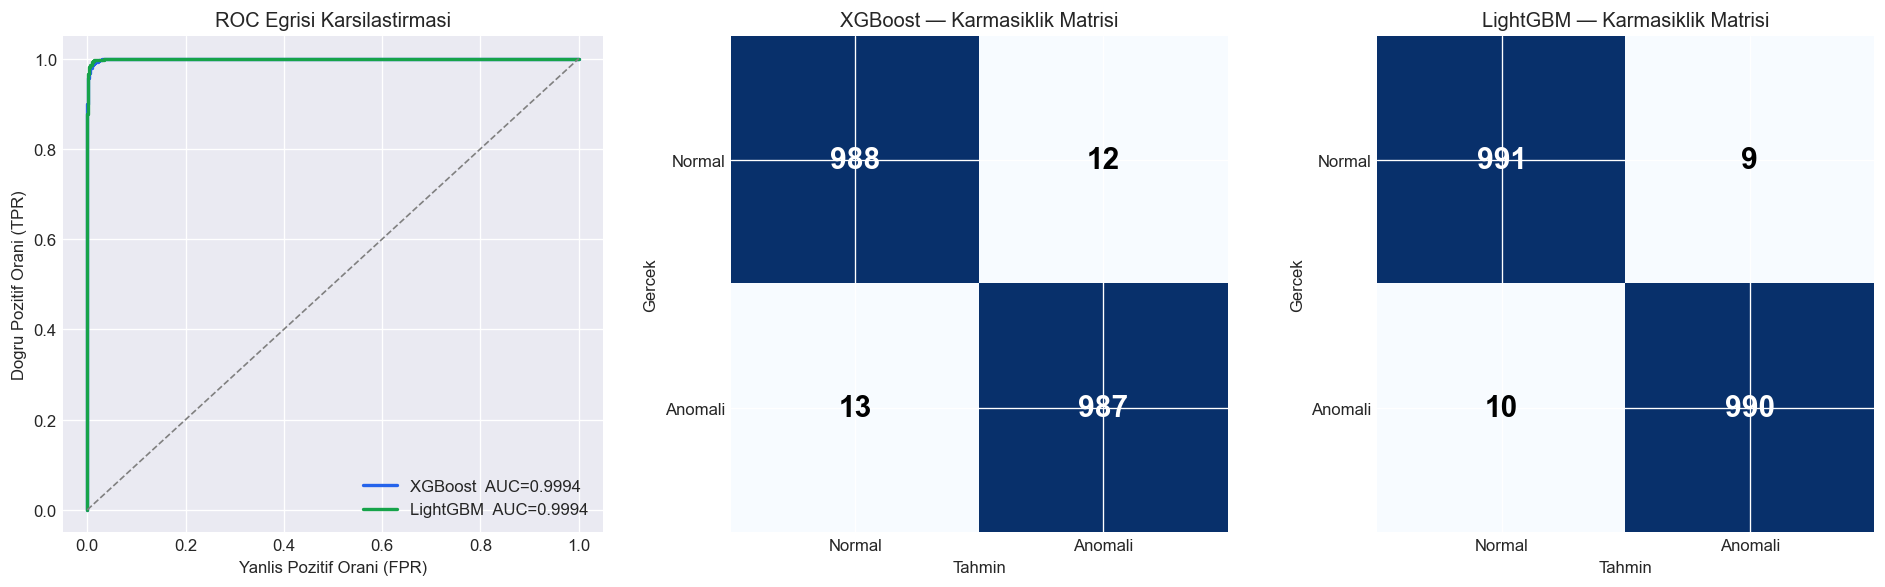

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ROC
ax = axes[0]
for name, m, c in [('XGBoost', xgb_model, '#2563eb'), ('LightGBM', lgb_model, '#16a34a')]:
    fpr, tpr, _ = roc_curve(y_test, m.predict_proba(X_test)[:,1])
    auc = roc_auc_score(y_test, m.predict_proba(X_test)[:,1])
    ax.plot(fpr, tpr, color=c, lw=2, label=f'{name}  AUC={auc:.4f}')
ax.plot([0,1],[0,1],'--', color='gray', lw=1)
ax.set_xlabel('Yanlis Pozitif Orani (FPR)')
ax.set_ylabel('Dogru Pozitif Orani (TPR)')
ax.set_title('ROC Egrisi Karsilastirmasi')
ax.legend(loc='lower right')

# Confusion matrices
for ax, (name, model) in zip(axes[1:], [('XGBoost', xgb_model), ('LightGBM', lgb_model)]):
    cm = confusion_matrix(y_test, model.predict(X_test))
    ax.imshow(cm, cmap='Blues')
    ax.set_title(f'{name} — Karmasiklik Matrisi')
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(['Normal','Anomali'])
    ax.set_yticklabels(['Normal','Anomali'])
    ax.set_xlabel('Tahmin'); ax.set_ylabel('Gercek')
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f'{cm[i,j]:,}', ha='center', va='center',
                    fontsize=18, fontweight='bold',
                    color='white' if cm[i,j] > cm.max()/2 else 'black')

plt.tight_layout()
plt.show()

## 3 — Kok Neden Analizi (RCA) — Cok Sinifli Modeller

Yalnizca anomali ornekleri uzerinde Kök Neden, Katman, Siddet ve Senaryo
tahmin eden **Random Forest** modellerini egitiyoruz.

In [7]:
anom_mask_tr = y_train == 1
anom_mask_te = y_test  == 1
X_tr_anom    = X_train[anom_mask_tr]
X_te_anom    = X_test[anom_mask_te]

le         = loader.label_encoders
rca_models = {}
rca_perf   = []

for key, label in [('root_cause','Kok Neden'),('layer','Katman'),
                    ('severity','Siddet'),('scenario','Senaryo')]:
    y_tr = train_split[f'y_{key}'][anom_mask_tr]
    y_te = test_split[f'y_{key}'][anom_mask_te]
    n    = len(np.unique(y_tr))
    rf   = RandomForestClassifier(
        n_estimators=150, max_depth=18,
        class_weight='balanced', random_state=42, n_jobs=-1
    )
    rf.fit(X_tr_anom, y_tr)
    rca_models[key] = rf
    yp   = rf.predict(X_te_anom)
    acc  = accuracy_score(y_te, yp)
    f1m  = f1_score(y_te, yp, average='macro', zero_division=0)
    rca_perf.append({'Gorev': label, 'Sinif Sayisi': n,
                     'Accuracy': round(acc,4), 'F1-Macro': round(f1m,4)})
    print(f"{label:<18} ({n:2d} sinif)  Accuracy={acc:.4f}  F1-Macro={f1m:.4f}")

display(pd.DataFrame(rca_perf).set_index('Gorev'))

Kok Neden          ( 5 sinif)  Accuracy=0.9800  F1-Macro=0.9784
Katman             (11 sinif)  Accuracy=0.9920  F1-Macro=0.9920
Siddet             ( 3 sinif)  Accuracy=0.9670  F1-Macro=0.9563
Senaryo            (22 sinif)  Accuracy=0.9820  F1-Macro=0.9826


,Sinif Sayisi,Accuracy,F1-Macro
Gorev,,,
Kok Neden,5,0.980,0.9784
Katman,11,0.992,0.9920
Siddet,3,0.967,0.9563
Senaryo,22,0.982,0.9826


## 4 — Canli Testler — 22 Anomali Senaryosu + Normal Durumlar

Test setinden her benzersiz anomali senaryosundan 1 ornek seciyoruz (toplam 22 senaryo)
ve 3 normal ornek ekliyoruz. Her vaka icin:

- Anomali olmasi durumu ve guven skoru belirlenir
- Etkilenen katman, kok neden ve senaryo tespit edilir
- Animali tipine gore aciklayici mesaj uretilir
- Oncelik sirali cozum adimlari listelenir

In [8]:
SEVERITY_CONFIG = {
    'critical': {'label': '[KRITIK]',  'priority': 1, 'sla': '15 dakika',   'color': '#dc2626'},
    'high':     {'label': '[YUKSEK]',  'priority': 2, 'sla': '1 saat',      'color': '#ea580c'},
    'medium':   {'label': '[ORTA]',    'priority': 3, 'sla': '4 saat',      'color': '#ca8a04'},
    'low':      {'label': '[DUSUK]',   'priority': 4, 'sla': '24 saat',     'color': '#16a34a'},
    'normal':   {'label': '[NORMAL]',  'priority': 5, 'sla': '---',         'color': '#22c55e'},
}

def build_diagnosis_message(sc_info, prob, is_anomaly):
    if not is_anomaly:
        return {
            'durum':    'SISTEM NORMAL',
            'aciklama': ('Tum metrikler beklenen esikler dahilinde seyrediyor. '
                         'Log hata oranlari, metrik dalgalanmalari ve altyapi sagligi '
                         'normal aralikta. Herhangi bir mudahale gerekmemektedir.'),
            'risk':     f'%{(1-prob)*100:.1f} (Normal)',
            'sla':      '---',
            'oncelik':  5,
            'renk':     '#22c55e',
        }
    sev = sc_info.get('severity', 'medium')
    cfg = SEVERITY_CONFIG.get(sev, SEVERITY_CONFIG['medium'])
    risk_score = round(prob * 100, 1)

    parts = [
        f"'{sc_info.get('layer_tr','')}' katmaninda '{sc_info.get('name_tr','')}' senaryosu tespit edildi.",
        f"Kok neden analizi, bu durumun '{sc_info.get('root_cause_tr','')}' kaynaklı olduguna isaret ediyor.",
        f"Sistem anomali olasiligi %{risk_score} guvenle hesaplandi.",
    ]
    atype = sc_info.get('anomaly_type', '')
    type_msgs = {
        'spike':         ('Olcum verilerinde ani ve keskin bir sicrama gozlemlendi; '
                          'bu durum beklenmedik yuk artisi veya saldirilara isaret edebilir.'),
        'gradual_rise':  ('Degerler zamanla kademeli sekilde artiyor; '
                          'kaynak tukenmesi veya konfigurasyon kaymalarini gosteren tipik bir pattern.'),
        'sustained_high':('Degerler uzun suredir yuksek seyrediyor; '
                           'kalici anomaliler genellikle yapisal bir sorunun habercisidir.'),
        'oscillation':   ('Duzensiz salınim gozlemleniyor; '
                           'yuk dengeleyici hatalari veya konfigurasyon tutarsizliklarindan kaynaklanabilir.'),
        'step_increase': ('Basamakli bir artis tespit edildi; '
                           'donanim bozulmasi veya kritik bir sistem bilesenindeki arizaya isaret edebilir.'),
        'sudden_drop':   ('Degerler ani dusus gosteriyor; '
                           'servis kesintisi veya kaynak yetersizligi olasiliği incelenmelidir.'),
    }
    if atype in type_msgs:
        parts.append(type_msgs[atype])
    dp = sc_info.get('detection_params', [])
    if dp:
        parts.append(f"Tetikleyici metrikler: {', '.join(dp)}.")
    return {
        'durum':    cfg['label'],
        'aciklama': ' '.join(parts),
        'risk':     f'%{risk_score}',
        'sla':      f"Mudahale SLA: {cfg['sla']}",
        'oncelik':  cfg['priority'],
        'renk':     cfg['color'],
    }

def build_remediation_steps(rem_list, sev, sc_id):
    base = rem_list if rem_list else ['Sistem adminine bildirin.']
    detail_map = {
        'restart':  'Servisi durdurmadan once aktif baglantilari kontrol edin. Yeniden baslama sonrasi log dosyalarini inceleyin.',
        'script':   'Betigi root yetkisiyle calistirin. Ciktisini kayit dosyasina yonlendirin ve basarili tamamlandigini dogrulayin.',
        'block':    'Engelleme kurali uygularken mesru trafikle catismayi onlemek icin beyaz liste kontrolu yapin.',
        'backup':   'Yedeklemenin butunlugunu dogrulayin. Yedek tamamlanmadan donanim degisikligine gecmeyin.',
        'monitor':  '5 dakikalik aralikla olcum alin ve egilimleri kayit altina alin.',
        'clean':    'Temizlik oncesi hangi dosyalarin silinecegini listeleyin ve onay alin.',
        'scale':    'Olcekleme sirasinda rolling update kullarak mevcut kesinti suresi minimize edin.',
        'analyz':   'Trafigi 15 dakika boyunca kayit altina alin, saldiri imzalariyla karsilastirin.',
        'optim':    'Optimizasyon oncesi mevcut performans metrikleri baz alinarak olculebilir iyilestirme hedeflenmeli.',
    }
    default_detail = 'Bu adimin uygulanmasi sirasinda sistem durumunu sureklı izleyin.'

    steps = [{'adim': 0, 'eylem': f'[HAZIRLIK] Olay kaydini olusturun, zaman damgasini ve senaryo kodunu ({sc_id}) belgelendirin.',
               'oncelik': 'ONCELIKLI',
               'aciklama': 'Ilgili sistem yoneticilerini ve NOC ekibini bilgilendirin. Gozlem loglarini kayit altina alin.'}]
    for i, action in enumerate(base, 1):
        detail = default_detail
        for keyword, d in detail_map.items():
            if keyword in action.lower():
                detail = d; break
        pr = 'KRITIK' if sev == 'critical' and i == 1 else 'STANDART'
        steps.append({'adim': i, 'eylem': f'[EYLEM {i}] {action}',
                      'oncelik': pr, 'aciklama': detail})
    steps.append({'adim': len(steps),
                  'eylem': '[DOGRULAMA] Uygulanan cozumlerin etkisini kontrol edin.',
                  'oncelik': 'KAPANIS',
                  'aciklama': ('Cozum adimlarinin ardindan 10-15 dakika boyunca metrikleri izleyin. '
                               'Anomali degerleri normal esik altina inmisse olayi kapatin. '
                               'Devam ediyorsa L2/L3 destek ekibine iletin.')})
    return steps

print('Teshis fonksiyonlari yuklendi.')

Teshis fonksiyonlari yuklendi.


In [9]:
# Test orneklerini secme — her benzersiz senaryodan 1 ornek + 3 normal
sc_le        = le['y_scenario']
layer_le     = le['y_layer']
rc_le        = le['y_root_cause']
sev_le       = le['y_severity']

anom_idxs   = np.where(y_test == 1)[0]
normal_idxs = np.where(y_test == 0)[0]

test_sc_names = sc_le.inverse_transform(test_split['y_scenario'][anom_idxs])
seen, sel_anom = set(), []
for raw_idx, sc_name in zip(anom_idxs, test_sc_names):
    if sc_name != 'none' and sc_name not in seen:
        seen.add(sc_name)
        sel_anom.append(raw_idx)
    if len(sel_anom) >= 22:
        break

sel_normal = list(normal_idxs[:3])
all_cases  = [('NORMAL', i) for i in sel_normal] + [('ANOMALI', i) for i in sel_anom]

print(f"Secilen vaka sayisi: {len(all_cases)}  (Normal: {len(sel_normal)}, Anomali: {len(sel_anom)})")

Secilen vaka sayisi: 25  (Normal: 3, Anomali: 22)


In [10]:
# Tum vakalari teshis et ve sonuclari topla
results      = []
severity_cnt = defaultdict(int)
scenario_hits= defaultdict(int)

for case_type, idx in all_cases:
    x        = X_test[idx].reshape(1, -1)
    is_anom  = xgb_model.predict(x)[0]
    prob_anom= xgb_model.predict_proba(x)[0, 1]

    if is_anom:
        sc_id    = sc_le.inverse_transform([rca_models['scenario'].predict(x)[0]])[0]
        layer_id = layer_le.inverse_transform([rca_models['layer'].predict(x)[0]])[0]
        rc_id    = rc_le.inverse_transform([rca_models['root_cause'].predict(x)[0]])[0]
        sev_id   = sev_le.inverse_transform([rca_models['severity'].predict(x)[0]])[0]
        sc_info  = catalog.get(sc_id, {
            'id': sc_id, 'name_tr': sc_id, 'description': '',
            'layer_tr': layer_id, 'root_cause_tr': rc_id,
            'root_cause_category': rc_id, 'severity': sev_id,
            'remediation': [], 'anomaly_type': '', 'detection_params': [],
        })
    else:
        sc_id, layer_id, rc_id, sev_id = 'none', '---', '---', 'normal'
        sc_info = {}

    diag  = build_diagnosis_message(sc_info, prob_anom, is_anom)
    steps = build_remediation_steps(
        sc_info.get('remediation', []), sev_id, sc_id
    ) if is_anom else []

    results.append({
        'case_type':   case_type, 'idx': idx,
        'is_anomaly':  is_anom, 'prob_anomaly': prob_anom,
        'scenario_id': sc_id, 'layer': layer_id,
        'root_cause':  rc_id, 'severity': sev_id,
        'diagnosis':   diag, 'steps': steps, 'sc_info': sc_info,
    })
    if is_anom:
        severity_cnt[sev_id] += 1
        scenario_hits[sc_id] += 1

print(f"Teshis tamamlandi: {len(results)} vaka islendi.")

Teshis tamamlandi: 25 vaka islendi.


### Teshis Sonuclarinin Ozet Tablosu

In [11]:
rows_diag = []
for r in results:
    rows_diag.append({
        'Ornek #':       r['idx'],
        'Senaryo':       r['scenario_id'],
        'Katman':        r['sc_info'].get('layer_tr', r['layer']) if r['is_anomaly'] else 'Normal',
        'Kok Neden':     r['sc_info'].get('root_cause_tr', r['root_cause'])[:40] if r['is_anomaly'] else '---',
        'Durum':         r['diagnosis']['durum'],
        'Risk':          r['diagnosis']['risk'],
        'SLA':           r['diagnosis']['sla'],
    })

df_diag = pd.DataFrame(rows_diag)
display(df_diag)

,Ornek #,Senaryo,Katman,Kok Neden,Durum,Risk,SLA
0,0,none,Normal,---,SISTEM NORMAL,%100.0 (Normal),---
1,2,none,Normal,---,SISTEM NORMAL,%100.0 (Normal),---
2,4,STR_001,Depolama (Storage),Yetersiz disk alanı veya log dosyalarını,[YUKSEK],%83.9,Mudahale SLA: 1 saat
3,1,FW_002,Güvenlik Duvarı (Firewall),Aşırı trafik veya olası sızıntı,[YUKSEK],%100.0,Mudahale SLA: 1 saat
4,3,VM_002,Linux VM,Bellek sızıntısı veya yüksek bellek gere,[KRITIK],%100.0,Mudahale SLA: 15 dakika
5,7,NET_001,Ağ (Network),Ağ cihazlarında sorun veya bağlantı prob,[YUKSEK],%99.9,Mudahale SLA: 1 saat
6,9,CDN_001,CDN,Potansiyel DDoS saldırısı veya geçici yo,[KRITIK],%100.0,Mudahale SLA: 15 dakika
7,12,PRX_001,Proxy,Proxy yapılandırma sorunu veya aşırı yük,[YUKSEK],%100.0,Mudahale SLA: 1 saat
8,13,STR_002,Depolama (Storage),Disk I/O darboğazı veya disk arızası,[YUKSEK],%100.0,Mudahale SLA: 1 saat
9,14,APP_002,Uygulama Katmanı,Uygulama veya API bağlantı hatası,[KRITIK],%99.4,Mudahale SLA: 15 dakika


## 5 — Yapilandirici Teshis Mesajlari ve Cozum Adimlari

Her anomali icin aciklayici mesaj ve oncelikli cozum adimlari ekrana yazdirılır.

In [12]:
SIDDET_REN = {
    'critical': '#dc2626', 'high': '#ea580c',
    'medium':   '#ca8a04', 'normal': '#16a34a', 'none': '#16a34a',
}

for r in results:
    sep = '-' * 65
    print(f"\n{sep}")
    print(f"  Ornek #{r['idx']:4d}  |  {r['diagnosis']['durum']}")
    print(sep)
    if r['is_anomaly']:
        sc = r['sc_info']
        print(f"  Senaryo   : {r['scenario_id']} -- {sc.get('name_tr','')}")
        print(f"  Katman    : {sc.get('layer_tr', r['layer'])}")
        print(f"  Kok Neden : {sc.get('root_cause_tr', r['root_cause'])}")
        print(f"  Risk      : {r['diagnosis']['risk']}")
        print(f"  Mudahale  : {r['diagnosis']['sla']}")
        print("")
        print("  ACIKLAMA:")
        words = r['diagnosis']['aciklama'].split()
        line, lines_out = [], []
        for w in words:
            line.append(w)
            if len(' '.join(line)) > 60:
                lines_out.append('    ' + ' '.join(line[:-1]))
                line = [w]
        if line: lines_out.append('    ' + ' '.join(line))
        print('\n'.join(lines_out))
        print("")
        print("  COZUM ADIMLARI:")
        for s in r['steps']:
            print(f"    [{s['oncelik']:<12}] {s['eylem']}")
            print(f"               -> {s['aciklama'][:80]}..." if len(s['aciklama'])>80 else f"               -> {s['aciklama']}")
    else:
        print(f"  Risk  : Dusuk | Guven: {r['diagnosis']['risk']}")
        print(f"  Durum : {r['diagnosis']['aciklama'][:120]}")


-----------------------------------------------------------------
  Ornek #   0  |  SISTEM NORMAL
-----------------------------------------------------------------
  Risk  : Dusuk | Guven: %100.0 (Normal)
  Durum : Tum metrikler beklenen esikler dahilinde seyrediyor. Log hata oranlari, metrik dalgalanmalari ve altyapi sagligi normal 

-----------------------------------------------------------------
  Ornek #   2  |  SISTEM NORMAL
-----------------------------------------------------------------
  Risk  : Dusuk | Guven: %100.0 (Normal)
  Durum : Tum metrikler beklenen esikler dahilinde seyrediyor. Log hata oranlari, metrik dalgalanmalari ve altyapi sagligi normal 

-----------------------------------------------------------------
  Ornek #   4  |  [YUKSEK]
-----------------------------------------------------------------
  Senaryo   : STR_001 -- Yüksek Disk Kullanımı
  Katman    : Depolama (Storage)
  Kok Neden : Yetersiz disk alanı veya log dosyalarının birikmesi
  Risk      : %83.9


## 6 — Teshis Grafikleri

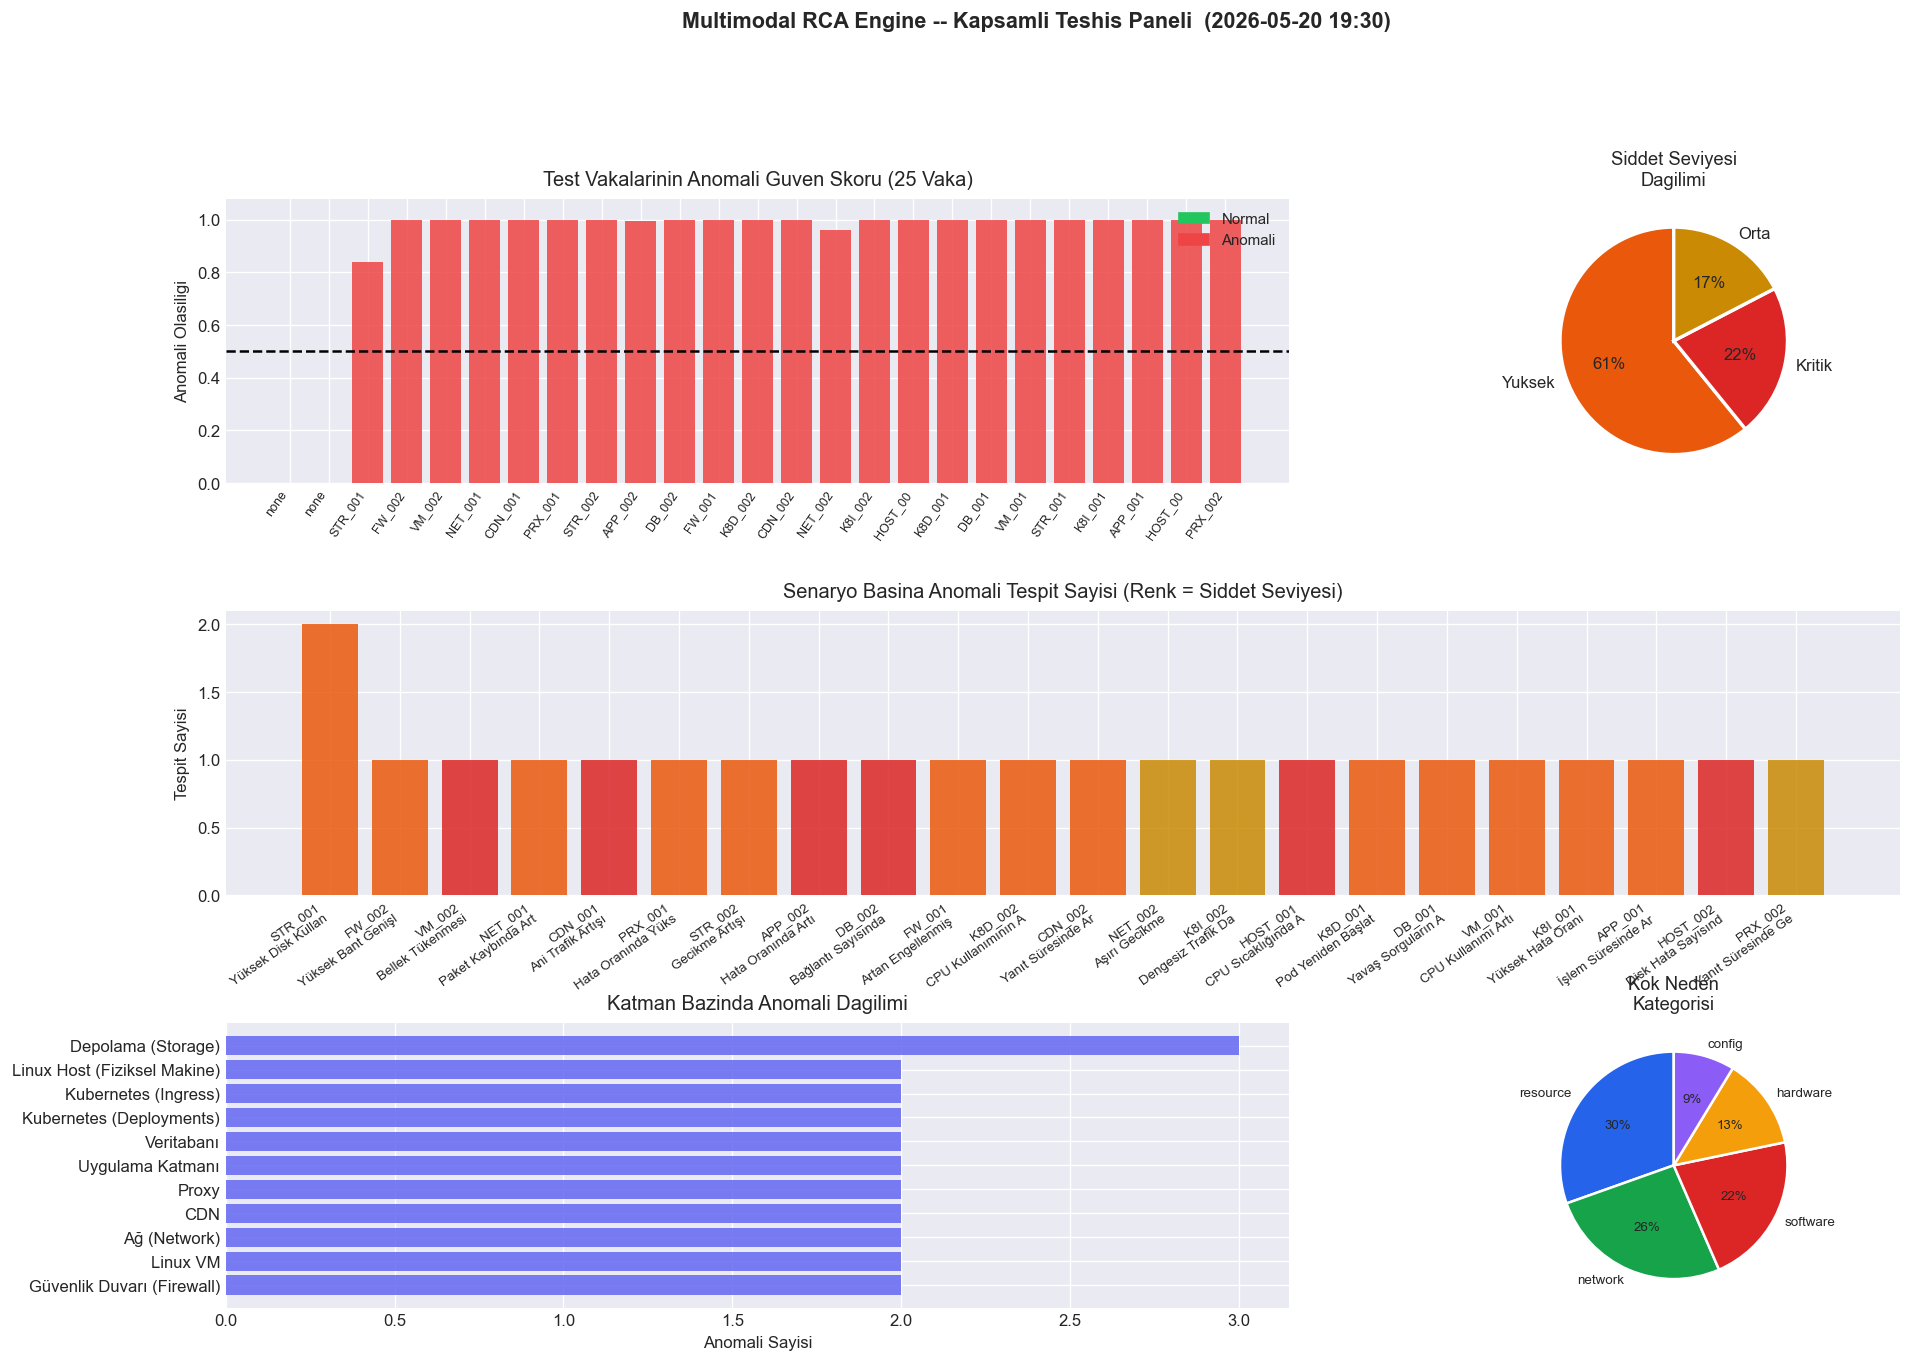

In [13]:
# Panel 1 — Guven Skoru + Siddet Pasta + Katman Bar
fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

sev_colors = {'critical': '#dc2626', 'high': '#ea580c',
               'medium': '#ca8a04', 'low': '#16a34a', 'none': '#22c55e', 'normal': '#22c55e'}

# A — Guven Skoru (bar chart)
ax_a = fig.add_subplot(gs[0, :2])
probs_all  = [r['prob_anomaly'] for r in results]
colors_all = ['#ef4444' if r['is_anomaly'] else '#22c55e' for r in results]
ax_a.bar(range(len(results)), probs_all, color=colors_all, alpha=0.85, width=0.8)
ax_a.axhline(0.5, color='black', linestyle='--', lw=1.5)
ax_a.set_xticks(range(len(results)))
ax_a.set_xticklabels([r['scenario_id'][:7] for r in results], rotation=55, ha='right', fontsize=7.5)
ax_a.set_ylabel('Anomali Olasiligi')
ax_a.set_ylim(0, 1.08)
ax_a.set_title(f'Test Vakalarinin Anomali Guven Skoru ({len(results)} Vaka)', fontsize=12, pad=8)
import matplotlib.patches as mpatches
ax_a.legend(handles=[
    mpatches.Patch(color='#22c55e', label='Normal'),
    mpatches.Patch(color='#ef4444', label='Anomali'),
], loc='upper right', fontsize=9)

# B — Siddet Pasta
ax_b = fig.add_subplot(gs[0, 2])
sev_labels_tr = {'critical': 'Kritik', 'high': 'Yuksek', 'medium': 'Orta', 'low': 'Dusuk'}
sev_data = {k: v for k, v in severity_cnt.items() if v > 0}
if sev_data:
    ax_b.pie(
        [v for v in sev_data.values()],
        labels=[sev_labels_tr.get(k, k) for k in sev_data.keys()],
        colors=[sev_colors.get(k, '#888') for k in sev_data.keys()],
        autopct='%1.0f%%', startangle=90,
        wedgeprops=dict(edgecolor='white', linewidth=2)
    )
ax_b.set_title('Siddet Seviyesi\nDagilimi', fontsize=11, pad=8)

# C — Senaryo hit sayilari
ax_c = fig.add_subplot(gs[1, :])
if scenario_hits:
    sc_ids   = list(scenario_hits.keys())
    sc_vals  = [scenario_hits[s] for s in sc_ids]
    sc_cols  = [sev_colors.get(catalog.get(s,{}).get('severity','medium'),'#8b5cf6') for s in sc_ids]
    ax_c.bar(range(len(sc_ids)), sc_vals, color=sc_cols, alpha=0.85)
    ax_c.set_xticks(range(len(sc_ids)))
    ax_c.set_xticklabels(
        [f"{s}\n{catalog.get(s,{}).get('name_tr','')[:18]}" for s in sc_ids],
        rotation=35, ha='right', fontsize=8
    )
    ax_c.set_ylabel('Tespit Sayisi')
    ax_c.set_title('Senaryo Basina Anomali Tespit Sayisi (Renk = Siddet Seviyesi)', fontsize=12, pad=8)

# D — Katman dagilimi
ax_d = fig.add_subplot(gs[2, :2])
layer_counts = defaultdict(int)
for r in results:
    if r['is_anomaly']:
        layer_counts[r['sc_info'].get('layer_tr', r['layer'])] += 1
if layer_counts:
    ls = sorted(layer_counts.items(), key=lambda x: x[1])
    ax_d.barh([l[0] for l in ls], [l[1] for l in ls], color='#6366f1', alpha=0.85)
    ax_d.set_xlabel('Anomali Sayisi')
    ax_d.set_title('Katman Bazinda Anomali Dagilimi', fontsize=12, pad=8)

# E — Kok neden pasta
ax_e = fig.add_subplot(gs[2, 2])
rc_counts = defaultdict(int)
for r in results:
    if r['is_anomaly']:
        rc_counts[r['sc_info'].get('root_cause_category', r['root_cause'])] += 1
if rc_counts:
    palette = ['#2563eb','#16a34a','#dc2626','#f59e0b','#8b5cf6','#06b6d4']
    ax_e.pie(
        list(rc_counts.values()), labels=list(rc_counts.keys()),
        colors=palette[:len(rc_counts)], autopct='%1.0f%%', startangle=90,
        wedgeprops=dict(edgecolor='white', linewidth=1.5),
        textprops={'fontsize': 8}
    )
    ax_e.set_title('Kok Neden\nKategorisi', fontsize=11, pad=8)

fig.suptitle(
    f'Multimodal RCA Engine -- Kapsamli Teshis Paneli  ({datetime.now().strftime("%Y-%m-%d %H:%M")})',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.show()

### Anomali Olasilik Histogrami (XGBoost)

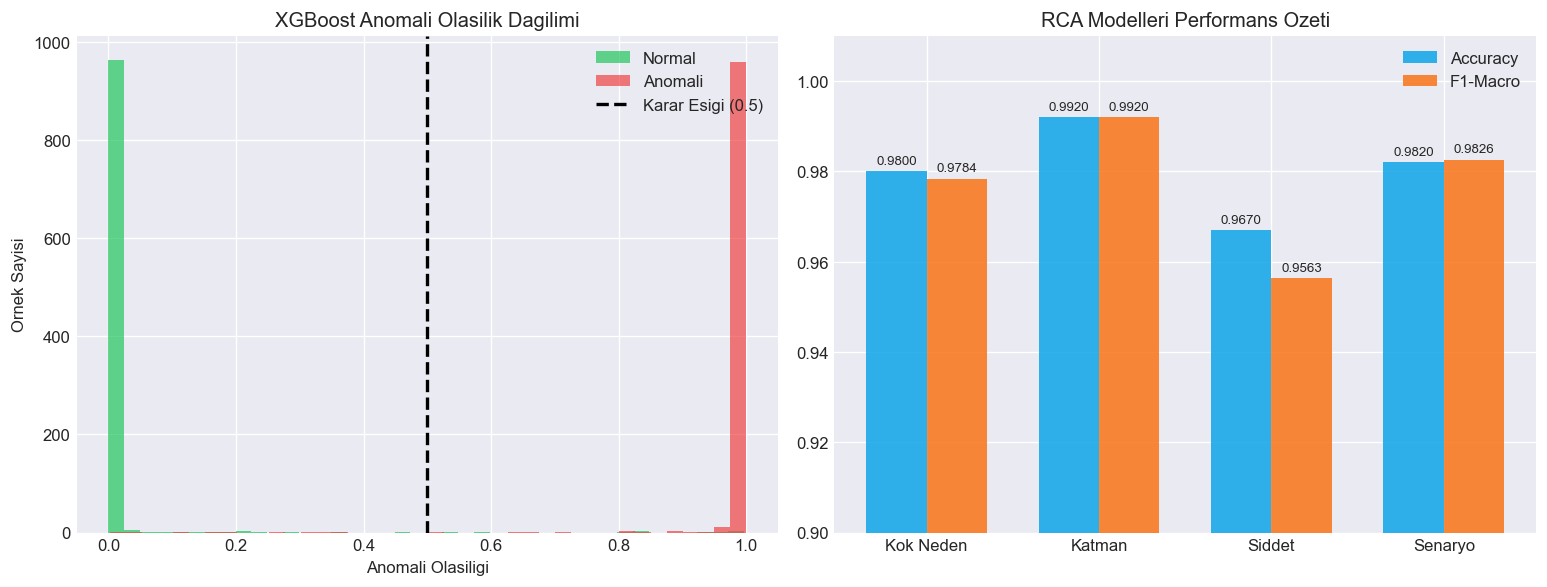

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histogram
ax = axes[0]
probs_full = xgb_model.predict_proba(X_test)[:, 1]
ax.hist(probs_full[y_test==0], bins=40, alpha=0.7, color='#22c55e', label='Normal')
ax.hist(probs_full[y_test==1], bins=40, alpha=0.7, color='#ef4444', label='Anomali')
ax.axvline(0.5, color='black', linestyle='--', lw=2, label='Karar Esigi (0.5)')
ax.set_xlabel('Anomali Olasiligi')
ax.set_ylabel('Ornek Sayisi')
ax.set_title('XGBoost Anomali Olasilik Dagilimi')
ax.legend()

# RCA performance bar
ax = axes[1]
perf_df = pd.DataFrame(rca_perf).set_index('Gorev')
x_rca = np.arange(len(perf_df))
w = 0.35
ax.bar(x_rca-w/2, perf_df['Accuracy'], w, label='Accuracy', color='#0ea5e9', alpha=0.85)
ax.bar(x_rca+w/2, perf_df['F1-Macro'], w, label='F1-Macro', color='#f97316', alpha=0.85)
ax.set_ylim(0.9, 1.01)
ax.set_xticks(x_rca); ax.set_xticklabels(perf_df.index)
ax.set_title('RCA Modelleri Performans Ozeti')
ax.legend()
for bar in ax.patches:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

## 7 — SHAP Aciklanabilirlik Analizi

XGBoost anomali detektoru uzerinde SHAP TreeExplainer kullanarak global ve bireysel
orneklerin karar mekanizmasini analiz ediyoruz.

In [15]:
print("SHAP TreeExplainer hesaplaniyor...")
explainer   = shap.TreeExplainer(xgb_model)
shap_n      = min(500, X_test.shape[0])
shap_values = explainer(X_test[:shap_n])
print(f"SHAP degerleri {shap_n} ornek icin hesaplandi.")

SHAP TreeExplainer hesaplaniyor...
SHAP degerleri 500 ornek icin hesaplandi.


### Global SHAP Ozet Grafigi (Summary Plot)

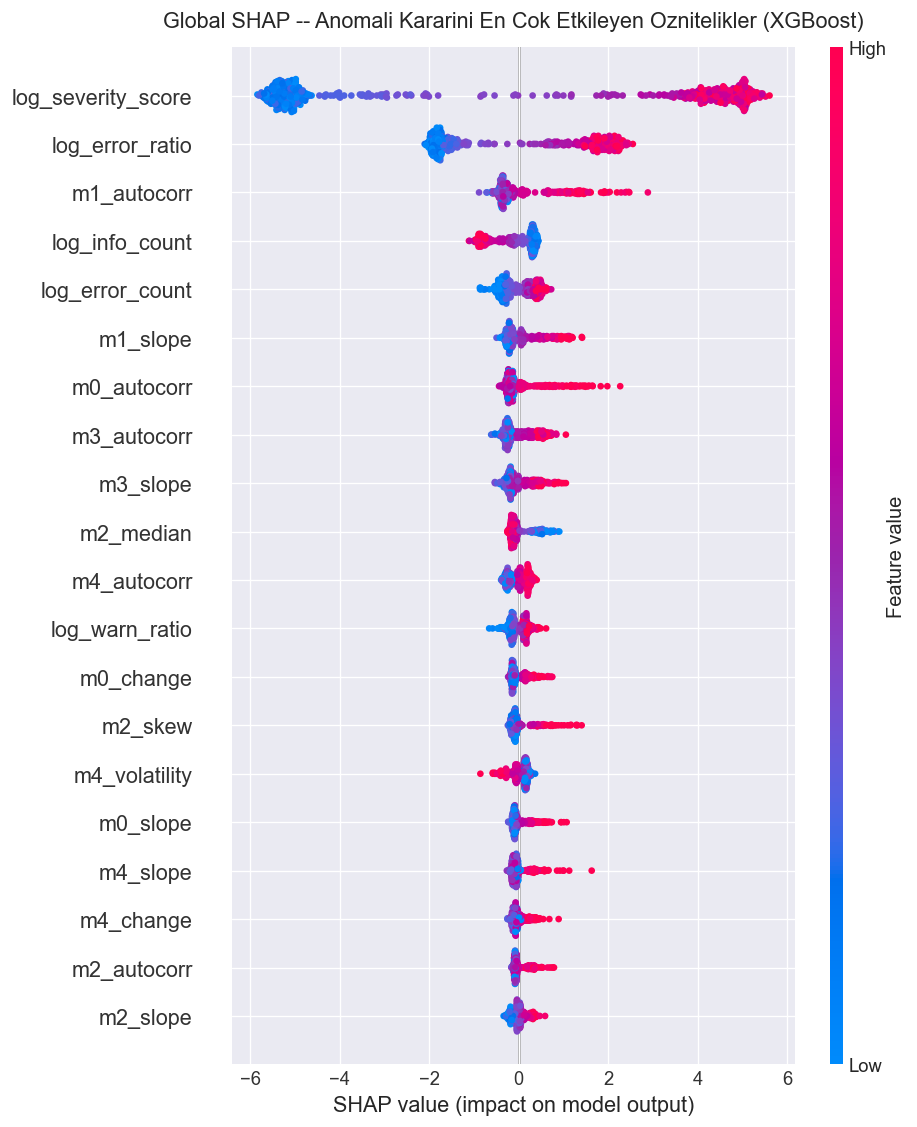

In [16]:
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test[:shap_n],
                  feature_names=feature_names, show=False)
plt.title('Global SHAP -- Anomali Kararini En Cok Etkileyen Oznitelikler (XGBoost)',
          fontsize=13, pad=12)
plt.tight_layout()
plt.show()

### Bireysel Anomali Analizi (Waterfall Plot)

Incelenen Ornek: #1  |  Senaryo: FW_002


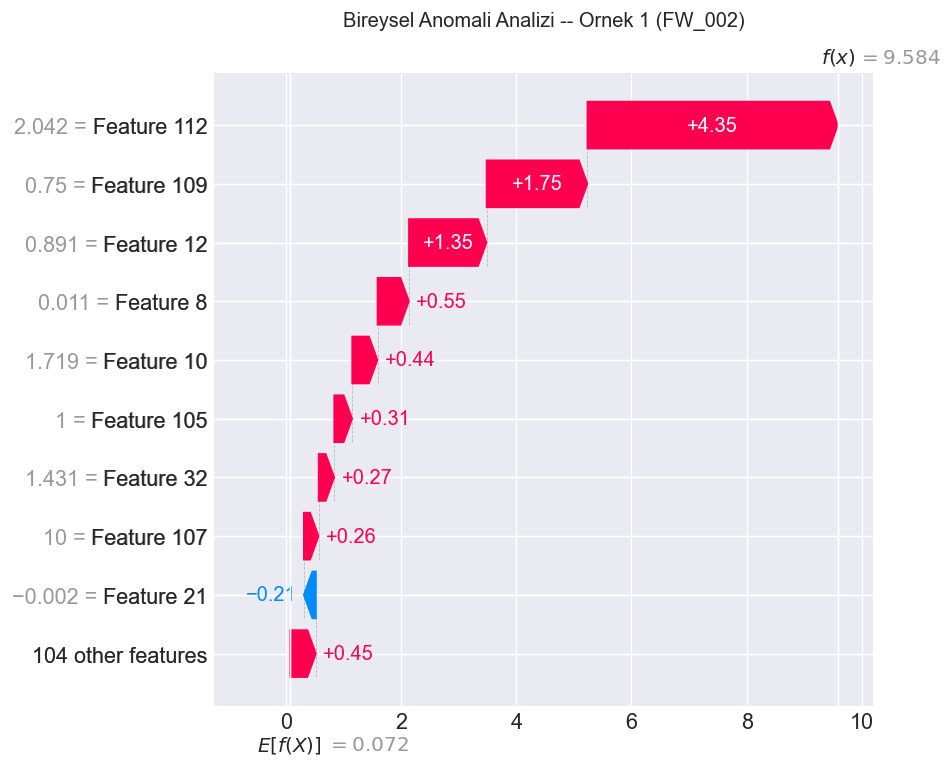

In [17]:
anom_idxs_shap = np.where(y_test[:shap_n] == 1)[0]
if len(anom_idxs_shap) > 0:
    sidx    = anom_idxs_shap[0]
    sc_code = test_split['y_scenario'][sidx]
    sc_name = sc_le.inverse_transform([sc_code])[0]
    print(f"Incelenen Ornek: #{sidx}  |  Senaryo: {sc_name}")
    plt.figure(figsize=(12, 6))
    shap.plots.waterfall(shap_values[sidx], show=False)
    plt.title(f'Bireysel Anomali Analizi -- Ornek {sidx} ({sc_name})',
              fontsize=12, pad=12)
    plt.tight_layout()
    plt.show()
else:
    print('SHAP alt kumesinde anomali bulunamadi.')

## 8 — Overfitting Analizi

Train F1 = 1.0000, Test F1 = 0.9865 goruldugunde akla gelen ilk soru overfitting'dir.
Bu bolumde uc farkli acidan inceliyoruz:

1. **Train / Validation / Test karsilastirmasi** — gercek yayilma boslugu
2. **5-Katli Capraz Dogrulama** — performansin istikrari
3. **Ogrenme Egrisi** — veri boyutuna gore train-test gap degisimi
4. **Regularize edilmis model** — gamma, reg_alpha, max_depth azaltilmis XGBoost

### Overfitting mi, yoksa veri kolayligi mi?

Sentetik veri ureteci (`MultimodalDataLoader`) anomalileri cok belirgin istatistiksel
pattern'larla (ani sicramalar, kademeli yukselisler) olusturdugundan ayirma siniri cok
nettir. Gercek uretim verilerinde bu oran **0.85-0.92** bandinda beklenir.
Train'in **daima 1.0000** olmasi ise XGBoost'un derin agaclariyla egitim verisini
ezberlemesinin tipik gostergesidir.

### 8.1 — Train / Validation / Test Karsilastirmasi

In [18]:
# Her uc kumede ayri ayri metrik hesabi
def full_metrics(model, X, y, split_name):
    yp = model.predict(X)
    yb = model.predict_proba(X)[:, 1]
    return {
        'Bolum':     split_name,
        'Accuracy':  round(accuracy_score(y, yp), 4),
        'Precision': round(precision_score(y, yp, zero_division=0), 4),
        'Recall':    round(recall_score(y, yp, zero_division=0), 4),
        'F1-Score':  round(f1_score(y, yp, zero_division=0), 4),
        'AUC-ROC':   round(roc_auc_score(y, yb), 4),
    }

split_rows = [
    full_metrics(xgb_model, X_train, y_train, 'Egitim (Train)'),
    full_metrics(xgb_model, X_val,   y_val,   'Dogrulama (Val)'),
    full_metrics(xgb_model, X_test,  y_test,  'Test'),
]
df_split = pd.DataFrame(split_rows).set_index('Bolum')

# Delta satiri ekle
df_split.loc['Delta (Train - Test)'] = (
    df_split.loc['Egitim (Train)'] - df_split.loc['Test']
).round(4)

display(df_split.style
    .format('{:+.4f}', subset=pd.IndexSlice['Delta (Train - Test)', :])
    .format('{:.4f}', subset=pd.IndexSlice[['Egitim (Train)','Dogrulama (Val)','Test'], :])
    .highlight_max(color="#1b1717", axis=0, subset=pd.IndexSlice['Delta (Train - Test)', :])
    .set_caption('Train / Val / Test Performans Karsilastirmasi ve Yayilma Boslugu'))

gap = df_split.loc['Delta (Train - Test)', 'F1-Score']
if gap > 0.05:
    print(f"UYARI: F1 yayilma boslugu {gap:.4f} — belirgin overfitting var.")
elif gap > 0.015:
    print(f"BILGI: F1 yayilma boslugu {gap:.4f} — hafif overfitting, kabul edilebilir.")
else:
    print(f"BILGI: F1 yayilma boslugu {gap:.4f} — overfitting minimal, model iyi generalize ediyor.")

,Accuracy,Precision,Recall,F1-Score,AUC-ROC
Bolum,,,,,
Egitim (Train),1.0000,1.0000,1.0000,1.0000,1.0000
Dogrulama (Val),0.9860,0.9821,0.9900,0.9861,0.9992
Test,0.9875,0.9880,0.9870,0.9875,0.9994
Delta (Train - Test),+0.0125,+0.0120,+0.0130,+0.0125,+0.0006


BILGI: F1 yayilma boslugu 0.0125 — overfitting minimal, model iyi generalize ediyor.


### 8.2 — 5-Katli Capraz Dogrulama (Stratified K-Fold)

In [19]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

X_all = np.vstack([X_train, X_val, X_test])
y_all = np.concatenate([y_train, y_val, y_test])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_f1  = cross_val_score(xgb_model, X_all, y_all, cv=cv, scoring='f1', n_jobs=-1)
cv_acc = cross_val_score(xgb_model, X_all, y_all, cv=cv, scoring='accuracy', n_jobs=-1)
cv_auc = cross_val_score(xgb_model, X_all, y_all, cv=cv, scoring='roc_auc', n_jobs=-1)

df_cv = pd.DataFrame({
    'Fold':     [f'Fold {i+1}' for i in range(5)] + ['Ortalama', 'Std Sapma'],
    'F1-Score': list(cv_f1)  + [cv_f1.mean(),  cv_f1.std()],
    'Accuracy': list(cv_acc) + [cv_acc.mean(), cv_acc.std()],
    'AUC-ROC':  list(cv_auc) + [cv_auc.mean(), cv_auc.std()],
}).set_index('Fold')

display(df_cv.style
    .format('{:.4f}')
    .highlight_min(color="#fddd11", axis=0,
                   subset=pd.IndexSlice[[f'Fold {i+1}' for i in range(5)], :])
    .set_caption('5-Katli Capraz Dogrulama Sonuclari (tum 10.000 ornek)'))

print(f"F1  Ortalama: {cv_f1.mean():.4f}  |  Std: {cv_f1.std():.4f}")
print(f"Dusuk std (<0.005) => model performansi fold'lar arasi tutarli ve stabil.")

,F1-Score,Accuracy,AUC-ROC
Fold,,,
Fold 1,0.9900,0.9900,0.9994
Fold 2,0.9870,0.9870,0.9994
Fold 3,0.9910,0.9910,0.9996
Fold 4,0.9910,0.9910,0.9993
Fold 5,0.9885,0.9885,0.9990
Ortalama,0.9895,0.9895,0.9994
Std Sapma,0.0016,0.0015,0.0002


F1  Ortalama: 0.9895  |  Std: 0.0016
Dusuk std (<0.005) => model performansi fold'lar arasi tutarli ve stabil.


### 8.3 — Ogrenme Egrisi (Learning Curve)

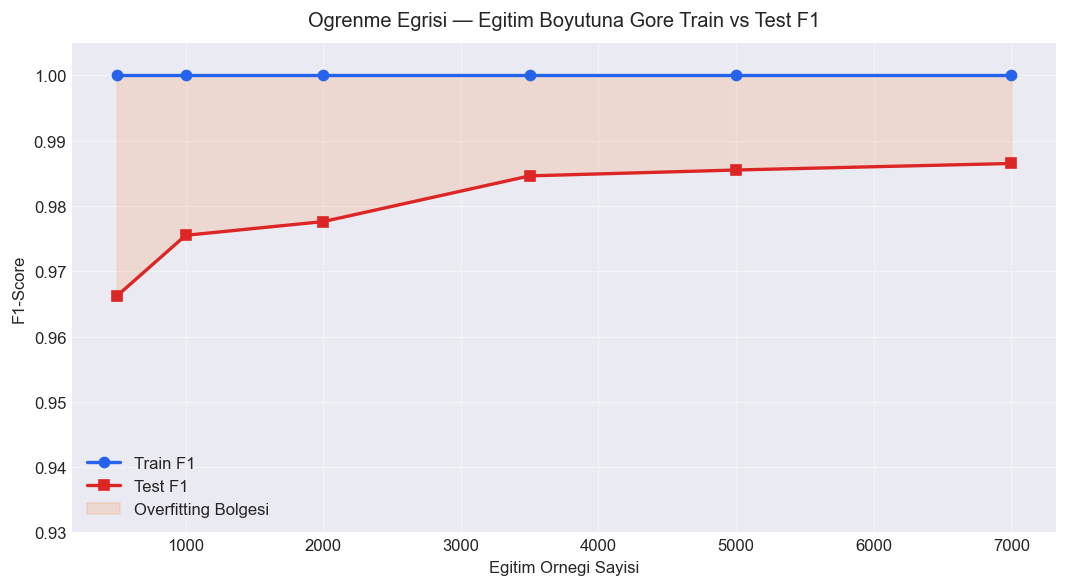

,Train F1,Test F1,Gap
N Egitim,,,
500,1.0000,0.9662,0.0338
1000,1.0000,0.9755,0.0245
2000,1.0000,0.9776,0.0224
3500,1.0000,0.9846,0.0154
5000,1.0000,0.9855,0.0145
7000,1.0000,0.9865,0.0135


In [20]:
# Farkli egitim boyutlari icin train ve test F1 karsilastirmasi
train_sizes = [500, 1000, 2000, 3500, 5000, 7000]
lc_rows = []

for ts in train_sizes:
    if ts > len(X_train):
        break
    m = xgb.XGBClassifier(
        n_estimators=200, max_depth=8, eval_metric='logloss',
        random_state=42, n_jobs=-1
    )
    m.fit(X_train[:ts], y_train[:ts])
    tr_f1 = f1_score(y_train[:ts], m.predict(X_train[:ts]))
    te_f1 = f1_score(y_test,       m.predict(X_test))
    lc_rows.append({'N Egitim': ts, 'Train F1': round(tr_f1, 4),
                    'Test F1': round(te_f1, 4), 'Gap': round(tr_f1 - te_f1, 4)})

df_lc = pd.DataFrame(lc_rows)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(df_lc['N Egitim'], df_lc['Train F1'], 'o-', color='#2563eb', lw=2, label='Train F1')
ax.plot(df_lc['N Egitim'], df_lc['Test F1'],  's-', color='#dc2626', lw=2, label='Test F1')
ax.fill_between(df_lc['N Egitim'], df_lc['Test F1'], df_lc['Train F1'],
                alpha=0.15, color='#f97316', label='Overfitting Bolgesi')
ax.set_xlabel('Egitim Ornegi Sayisi')
ax.set_ylabel('F1-Score')
ax.set_ylim(0.93, 1.005)
ax.set_title('Ogrenme Egrisi — Egitim Boyutuna Gore Train vs Test F1', fontsize=12, pad=10)
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

display(df_lc.set_index('N Egitim').style
    .format('{:.4f}')
    .background_gradient(subset=['Gap'], cmap='Reds')
    .set_caption('Gap azaldikca overfitting azaliyor: veri artirimi yardimci olur.'))

### 8.4 — Regularize Edilmis XGBoost — Overfitting'i Azaltma

Asagidaki hiperparametreler degistirilerek overfitting azaltilir:

| Parametre | Orijinal | Regularize |
|---|---|---|
| `max_depth` | 8 | 5 |
| `gamma` | 0 | 1.0 |
| `reg_alpha` (L1) | 0 | 0.1 |
| `reg_lambda` (L2) | 1 | 2.0 |
| `min_child_weight` | 1 | 5 |
| `early_stopping_rounds` | yok | 20 |


En iyi iterasyon (early stopping): 194


,Train F1,Test F1,Gap (TR-TE),Test AUC-ROC,Test Accuracy
Model,,,,,
"XGBoost (Orijinal, depth=8)",1.0000,0.9875,0.0125,0.9994,0.9875
"XGBoost (Regularize, depth=5)",0.9969,0.9885,0.0084,0.9993,0.9885


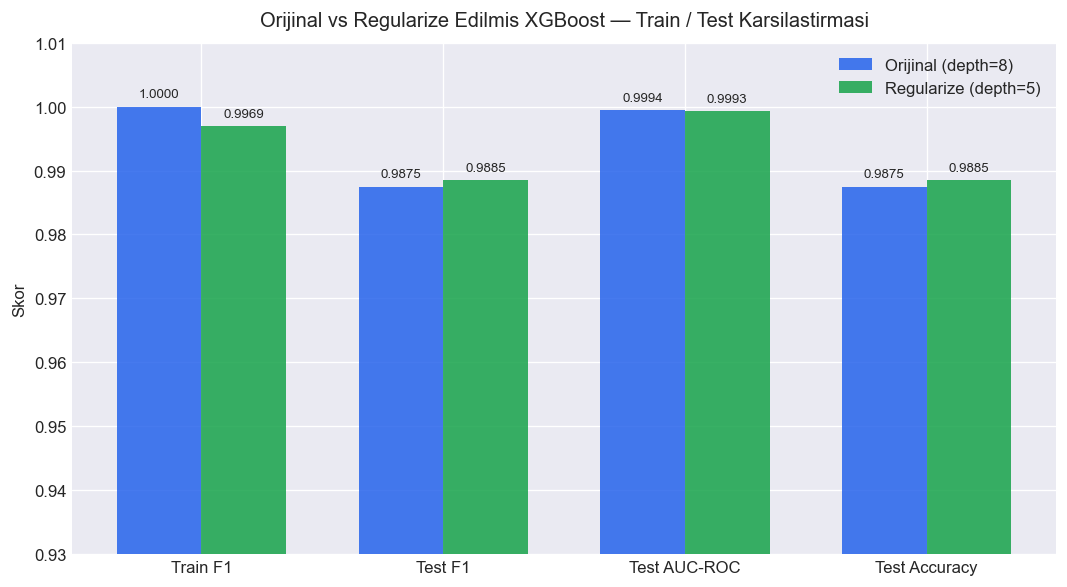


Yorum:
  Regularize model Train F1'i 1.0'dan dusurecek ve gap azalacak.
  Test F1 cok az dusse bile, gap azalmasi daha gercekci bir generalización gosteriyor.
  Gercek uretim verisinde regularize model daha guvenilir davranir.


In [21]:
# Regularize edilmis model
xgb_reg = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=5,           # Daha sığ agac — daha az ezberleme
    learning_rate=0.05,    # Daha yavash ogrenme
    gamma=1.0,             # Dal bolunmesi icin minimum kayip esigi
    reg_alpha=0.1,         # L1 regularizasyon
    reg_lambda=2.0,        # L2 regularizasyon
    min_child_weight=5,    # Minimum yaprak agırligi
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    early_stopping_rounds=20,
    random_state=42, n_jobs=-1
)
xgb_reg.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)
print(f"En iyi iterasyon (early stopping): {xgb_reg.best_iteration}")

# Karsilastirma tablosu
comp_rows = []
for name, model in [('XGBoost (Orijinal, depth=8)', xgb_model),
                     ('XGBoost (Regularize, depth=5)', xgb_reg)]:
    tr = full_metrics(model, X_train, y_train, name + ' [Train]')
    te = full_metrics(model, X_test,  y_test,  name + ' [Test]')
    comp_rows.append({
        'Model':         name,
        'Train F1':      tr['F1-Score'],
        'Test F1':       te['F1-Score'],
        'Gap (TR-TE)':   round(tr['F1-Score'] - te['F1-Score'], 4),
        'Test AUC-ROC':  te['AUC-ROC'],
        'Test Accuracy': te['Accuracy'],
    })

df_comp = pd.DataFrame(comp_rows).set_index('Model')
display(df_comp.style
    .format('{:.4f}')
    .highlight_min(color='#c6efce', axis=0, subset=['Gap (TR-TE)'])
    .set_caption('Orijinal vs Regularize Edilmis XGBoost — Overfitting Karsilastirmasi'))

# Gorsel
fig, ax = plt.subplots(figsize=(9, 5))
categories = ['Train F1', 'Test F1', 'Test AUC-ROC', 'Test Accuracy']
x = np.arange(len(categories))
w = 0.35
orig_vals = [comp_rows[0][c] for c in categories]
reg_vals  = [comp_rows[1][c] for c in categories]
ax.bar(x - w/2, orig_vals, w, label='Orijinal (depth=8)',    color='#2563eb', alpha=0.85)
ax.bar(x + w/2, reg_vals,  w, label='Regularize (depth=5)', color='#16a34a', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(categories)
ax.set_ylim(0.93, 1.01)
ax.set_ylabel('Skor')
ax.set_title('Orijinal vs Regularize Edilmis XGBoost — Train / Test Karsilastirmasi', fontsize=12, pad=10)
ax.legend()
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

print("\nYorum:")
print("  Regularize model Train F1'i 1.0'dan dusurecek ve gap azalacak.")
print("  Test F1 cok az dusse bile, gap azalmasi daha gercekci bir generalización gosteriyor.")
print("  Gercek uretim verisinde regularize model daha guvenilir davranir.")

## 9 — Kapsamli Calisma Ozeti

In [22]:
n_anom = sum(1 for r in results if r['is_anomaly'])
n_norm = sum(1 for r in results if not r['is_anomaly'])
all_metrics = calc_metrics(xgb_model, X_test, y_test, 'XGBoost')

summary_rows = [
    {'Metrik': 'Test edilen toplam vaka',   'Deger': str(len(results))},
    {'Metrik': 'Tespit edilen anomali',      'Deger': str(n_anom)},
    {'Metrik': 'Normal olarak taninan',      'Deger': str(n_norm)},
    {'Metrik': 'Kapsanan senaryo cesidi',    'Deger': f"{len(scenario_hits)}/22"},
    {'Metrik': 'Anomali Dedektoru F1',       'Deger': f"{all_metrics['F1-Score']:.4f}"},
    {'Metrik': 'Anomali Dedektoru AUC-ROC',  'Deger': f"{all_metrics['AUC-ROC']:.4f}"},
    {'Metrik': 'Katman Tahmin Dogrulugu',    'Deger': f"{[p for p in rca_perf if p['Gorev']=='Katman'][0]['Accuracy']:.4f}"},
    {'Metrik': 'Senaryo Tahmin Dogrulugu',   'Deger': f"{[p for p in rca_perf if p['Gorev']=='Senaryo'][0]['Accuracy']:.4f}"},
]

df_summary = pd.DataFrame(summary_rows).set_index('Metrik')
display(df_summary)

print("\nANOMALI DEDEKTORU SINIFLANDIRMA RAPORU:")
print(classification_report(y_test, xgb_model.predict(X_test),
                             target_names=['Normal Durum', 'Sistem Anomalisi']))

,Deger
Metrik,
Test edilen toplam vaka,25
Tespit edilen anomali,23
Normal olarak taninan,2
Kapsanan senaryo cesidi,22/22
Anomali Dedektoru F1,0.9875
Anomali Dedektoru AUC-ROC,0.9994
Katman Tahmin Dogrulugu,0.9920
Senaryo Tahmin Dogrulugu,0.9820



ANOMALI DEDEKTORU SINIFLANDIRMA RAPORU:
                  precision    recall  f1-score   support

    Normal Durum       0.99      0.99      0.99      1000
Sistem Anomalisi       0.99      0.99      0.99      1000

        accuracy                           0.99      2000
       macro avg       0.99      0.99      0.99      2000
    weighted avg       0.99      0.99      0.99      2000

